# Breast Cancer Classification using Neural Networks

**Project**: Classify breast tumors as **Malignant** (cancerous) or **Benign** (non-cancerous) using Machine Learning & Deep Learning.

**Dataset**: Wisconsin Breast Cancer Diagnostic Dataset (569 samples, 30 features)

**Labels**: `0` → Malignant | `1` → Benign

**Models Compared**: Logistic Regression · SVM · Random Forest · Neural Network

---

### Table of Contents

| Step | Section |
|------|---------|
| 1 | Setup & Imports |
| 2 | Data Loading |
| 3 | EDA — Basic Statistics |
| 4 | EDA — Advanced Visualization |
| 5 | Feature Engineering (PCA, Mutual Information) |
| 6 | Data Preprocessing |
| 7 | Model 1: Logistic Regression |
| 8 | Model 2: Support Vector Machine (SVM) |
| 9 | Model 3: Random Forest |
| 10 | Multi-Model Comparison |
| 11 | Neural Network — Build & Compile |
| 12 | Neural Network — Train |
| 13 | Advanced Evaluation (ROC, AUC, PR Curves) |
| 14 | Predictive System |
| 15 | Save & Load Model |

---
## Step 1: Setup & Imports

Import all the necessary libraries for data handling, visualization, preprocessing, machine learning, and deep learning.

In [1]:
# Step 1: Import Dependencies

# Core data libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Sklearn — Datasets & Preprocessing
import sklearn.datasets
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Sklearn — ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Sklearn — Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Sklearn — Feature Selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("\nAll libraries imported successfully!")

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3

All libraries imported successfully!


---
## Step 2: Data Loading

Load the Breast Cancer Wisconsin (Diagnostic) dataset from scikit-learn. This dataset contains **569 samples** with **30 numerical features** computed from digitized images of fine needle aspirates (FNA) of breast masses.

**Features** describe characteristics of the cell nuclei:
- 10 real-valued features x 3 statistics (mean, standard error, worst) = 30 features
- Radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension

In [2]:
# Step 2: Load the Dataset

# Load dataset
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

# Convert to DataFrame
data_frame = pd.DataFrame(
    breast_cancer_dataset.data,
    columns=breast_cancer_dataset.feature_names
)

# Add target column
data_frame['label'] = breast_cancer_dataset.target

# Display dataset info
print("=" * 60)
print("  BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET")
print("=" * 60)
print(f"  Samples:          {data_frame.shape[0]}")
print(f"  Features:         {data_frame.shape[1] - 1}")
print(f"  Target classes:   {dict(zip([0, 1], breast_cancer_dataset.target_names))}")
print(f"  Missing values:   {data_frame.isnull().sum().sum()}")
print("=" * 60)

  BREAST CANCER WISCONSIN (DIAGNOSTIC) DATASET
  Samples:          569
  Features:         30
  Target classes:   {0: np.str_('malignant'), 1: np.str_('benign')}
  Missing values:   0


In [3]:
# First 5 rows
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Last 5 rows
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


---
## Step 3: Exploratory Data Analysis — Basic Statistics

### 3.1 Dataset Shape & Data Types

In [5]:
# Shape
print(f"Dataset Shape: {data_frame.shape}")
print(f"  → {data_frame.shape[0]} rows (samples)")
print(f"  → {data_frame.shape[1]} columns ({data_frame.shape[1]-1} features + 1 label)")

print(f"\nData Types:")
print(data_frame.dtypes.value_counts().to_string())

Dataset Shape: (569, 31)
  → 569 rows (samples)
  → 31 columns (30 features + 1 label)

Data Types:
float64    30
int64       1


In [6]:
# Detailed info
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 3.2 Missing Values Check

In [7]:
# Check for missing values
missing = data_frame.isnull().sum()
print(f"Total missing values: {missing.sum()}")
if missing.sum() > 0:
    print("\nColumns with missing values:")
    print(missing[missing > 0])
else:
    print("No missing values found — dataset is clean!")

Total missing values: 0
No missing values found — dataset is clean!


### 3.3 Statistical Summary

In [8]:
# Descriptive statistics
data_frame.describe().T  # Transposed for better readability

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 3.4 Target Variable Distribution

In [9]:
# Class distribution
print("Target Variable Distribution:")
print("=" * 45)
label_counts = data_frame['label'].value_counts().sort_index()
for label, count in label_counts.items():
    name = breast_cancer_dataset.target_names[label]
    pct = (count / len(data_frame)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label} ({name:>9s}): {count:3d} samples ({pct:5.1f}%) {bar}")
print(f"{'=' * 45}")
print(f"  Total: {len(data_frame)} samples")
print(f"\n  Class ratio (Benign/Malignant): {label_counts[1]/label_counts[0]:.2f}")

Target Variable Distribution:
  0 (malignant): 212 samples ( 37.3%) ██████████████████
  1 (   benign): 357 samples ( 62.7%) ███████████████████████████████
  Total: 569 samples

  Class ratio (Benign/Malignant): 1.68


### 3.5 Group-wise Mean Comparison

In [10]:
# Mean by label
group_means = data_frame.groupby('label').mean()
print("Mean feature values by class:")
print("(0 = Malignant, 1 = Benign)")
group_means

Mean feature values by class:
(0 = Malignant, 1 = Benign)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


---
## Step 4: EDA — Advanced Visualization

### 4.1 Class Distribution (Bar Chart + Pie Chart)

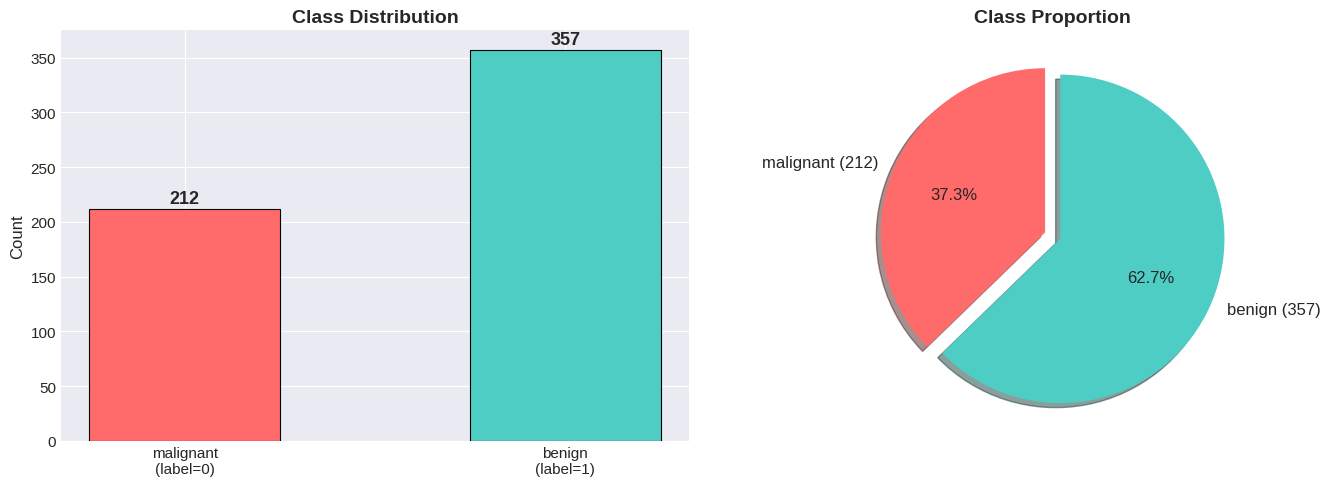

In [11]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4']
label_counts = data_frame['label'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(
    [f"{breast_cancer_dataset.target_names[i]}\n(label={i})" for i in label_counts.index],
    label_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    width=0.5
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontsize=13, fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[f"{breast_cancer_dataset.target_names[i]} ({v})" for i, v in zip(label_counts.index, label_counts.values)],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12},
    explode=(0.05, 0.05),
    shadow=True
)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Correlation Heatmap (Top 15 Features)

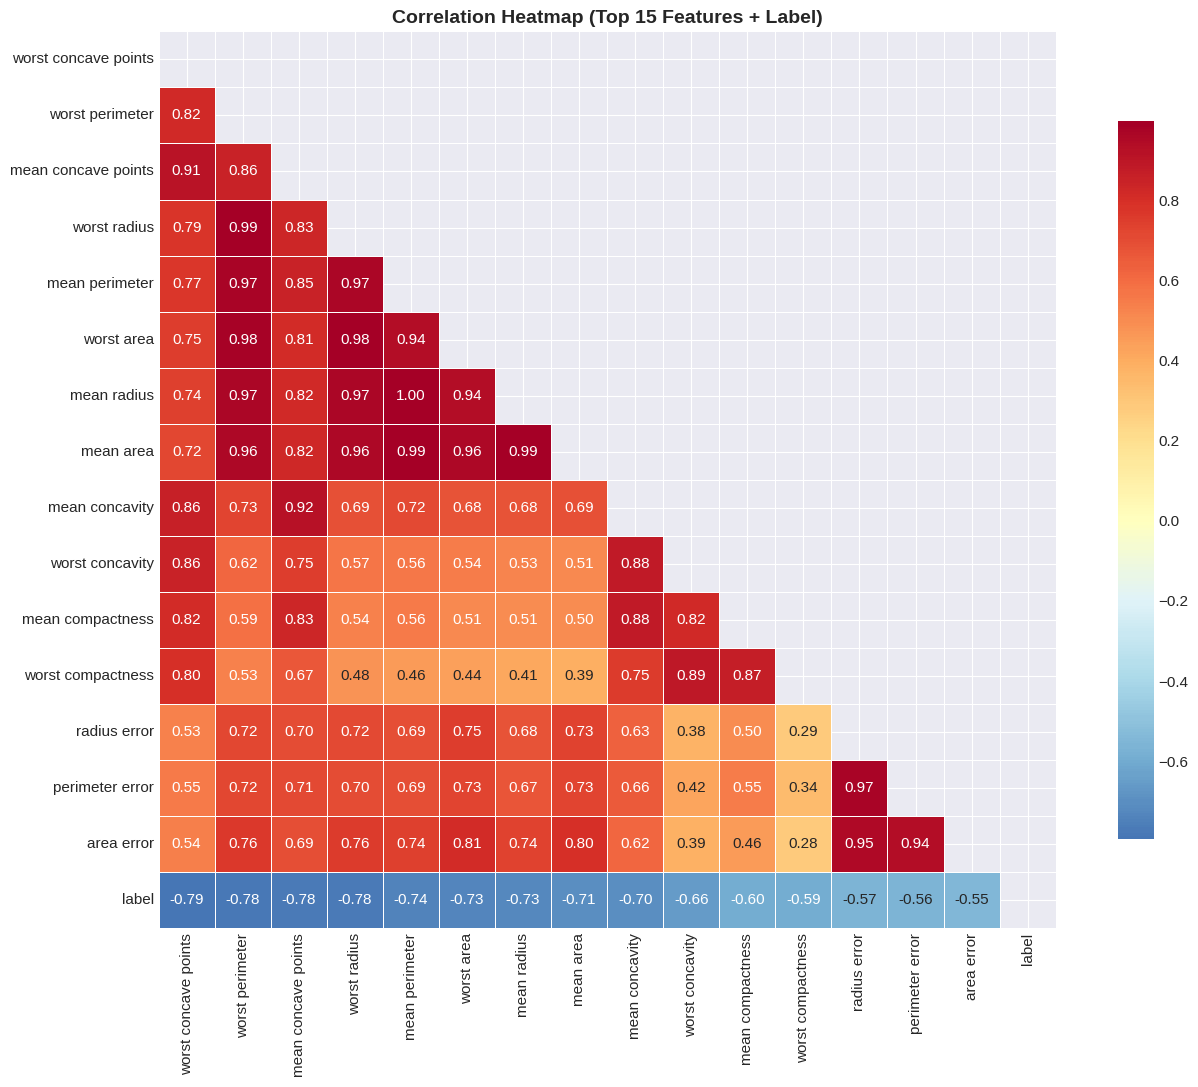


Top 10 features most correlated with label:
   1. worst concave points           | r = 0.7936
   2. worst perimeter                | r = 0.7829
   3. mean concave points            | r = 0.7766
   4. worst radius                   | r = 0.7765
   5. mean perimeter                 | r = 0.7426
   6. worst area                     | r = 0.7338
   7. mean radius                    | r = 0.7300
   8. mean area                      | r = 0.7090
   9. mean concavity                 | r = 0.6964
  10. worst concavity                | r = 0.6596


In [12]:
# Correlation heatmap — top 15 features
correlations = data_frame.corr()['label'].drop('label').abs().sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

plt.figure(figsize=(14, 11))
corr_matrix = data_frame[top_features + ['label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap (Top 15 Features + Label)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with label:")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i:2d}. {feat:<30s} | r = {corr:.4f}")

### 4.3 Boxplots — Outlier Detection

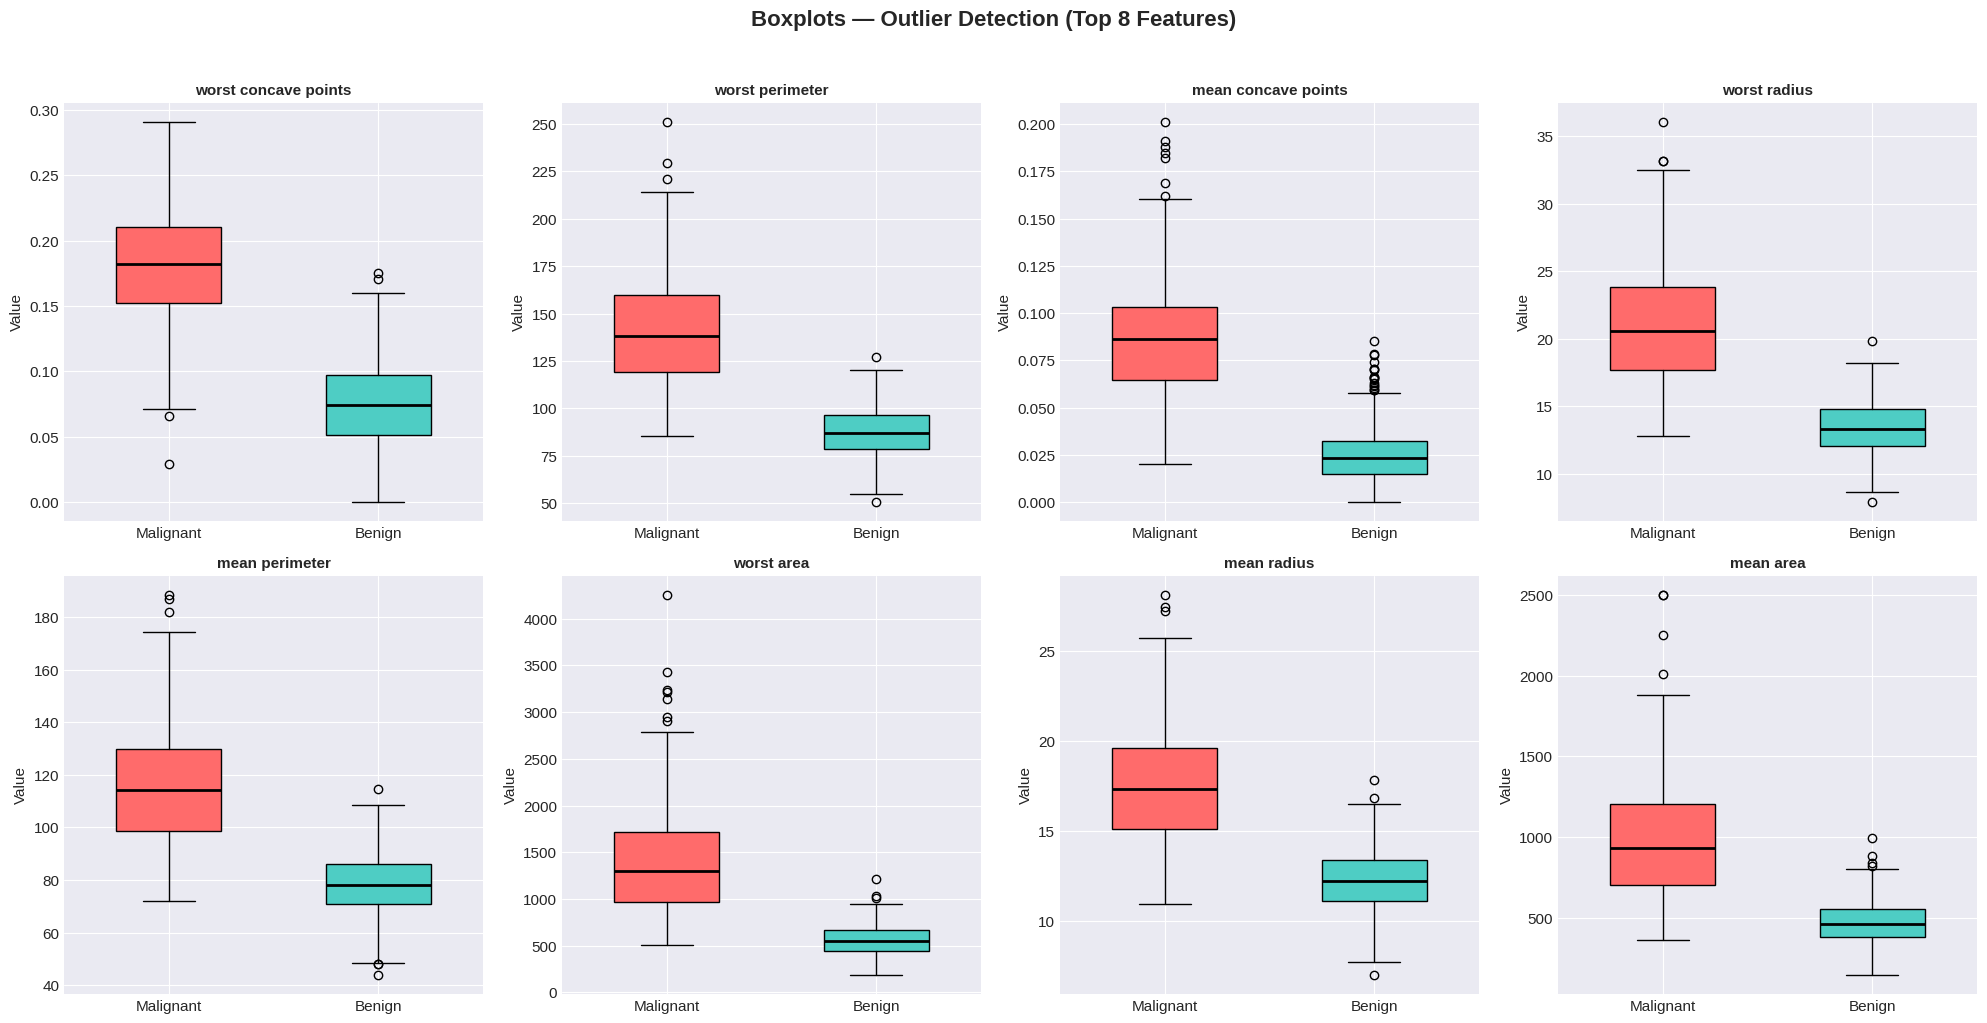

In [13]:
# Boxplots — top 8 features (outliers)
top_8 = correlations.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_8):
    data_malignant = data_frame[data_frame['label'] == 0][feature]
    data_benign = data_frame[data_frame['label'] == 1][feature]

    bp = axes[idx].boxplot(
        [data_malignant, data_benign],
        labels=['Malignant', 'Benign'],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#FF6B6B')
    bp['boxes'][1].set_facecolor('#4ECDC4')

    axes[idx].set_title(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection (Top 8 Features)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Violin Plots — Distribution Shape

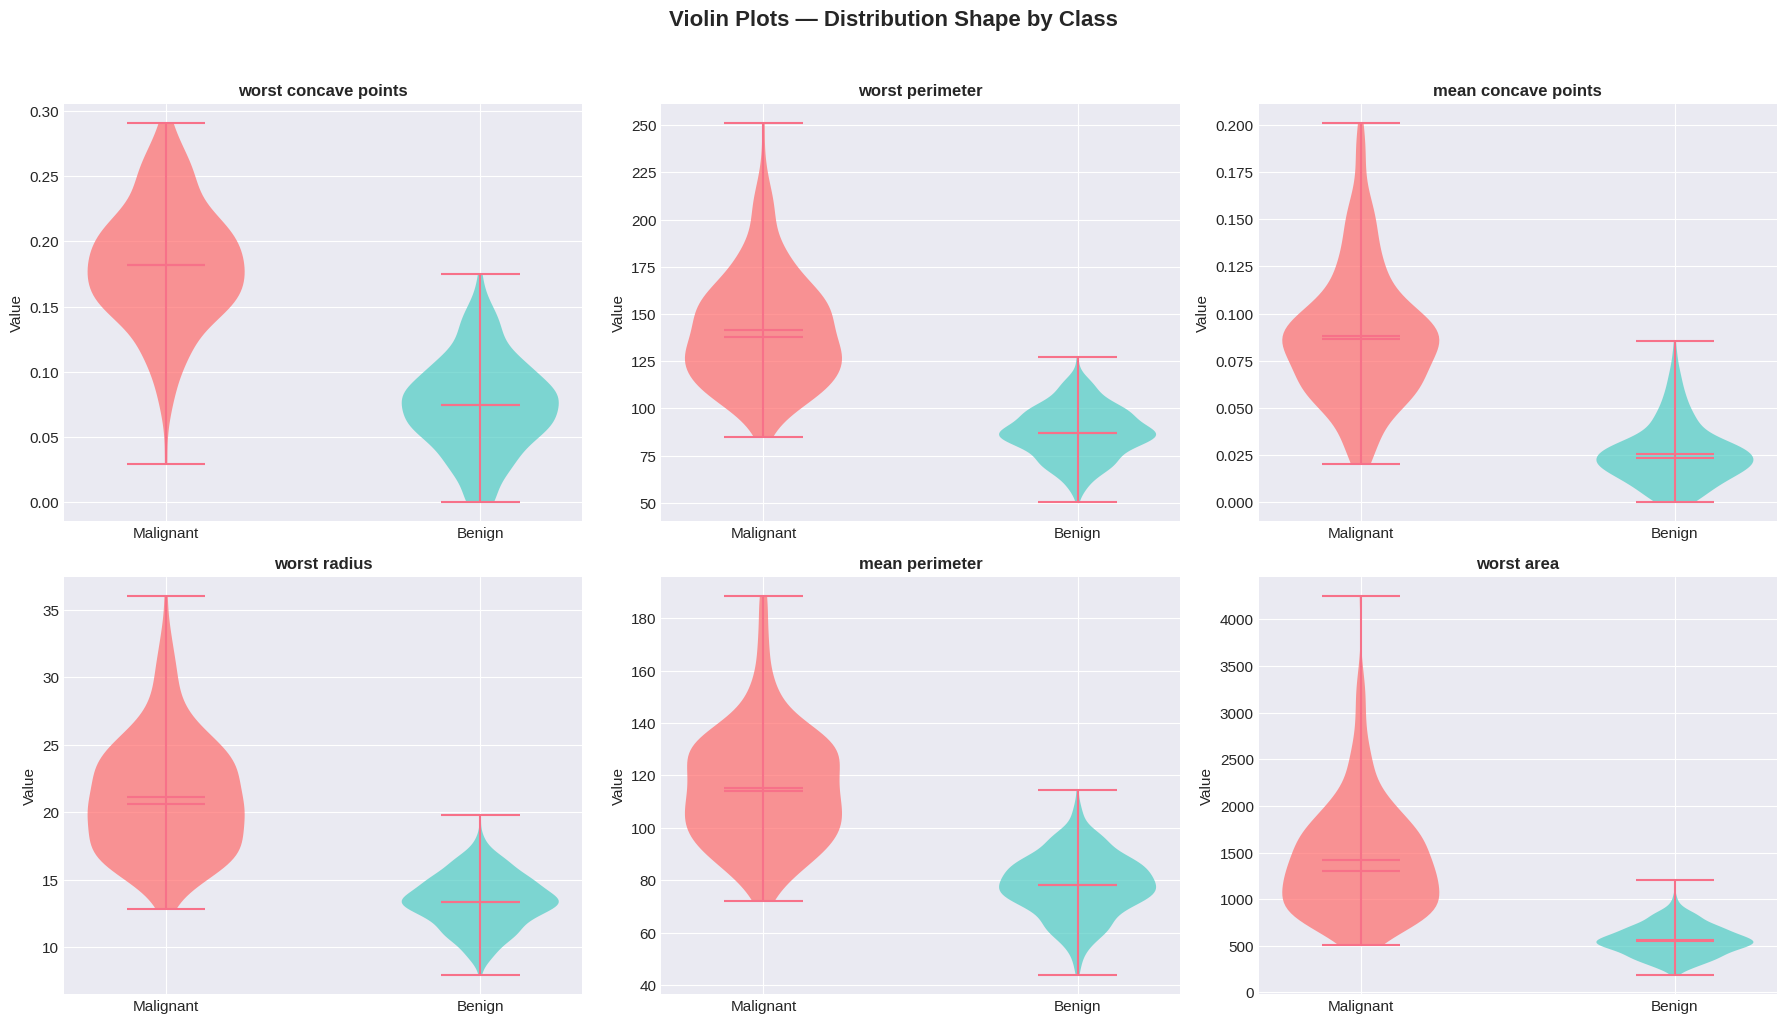

In [14]:
# Violin plots for top 6 features
top_6 = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_6):
    parts = axes[idx].violinplot(
        [data_frame[data_frame['label'] == 0][feature].values,
         data_frame[data_frame['label'] == 1][feature].values],
        positions=[0, 1],
        showmeans=True,
        showmedians=True
    )
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['#FF6B6B', '#4ECDC4'][i])
        pc.set_alpha(0.7)

    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Malignant', 'Benign'])
    axes[idx].set_ylabel('Value')

plt.suptitle('Violin Plots — Distribution Shape by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Feature Histograms — Distribution by Class

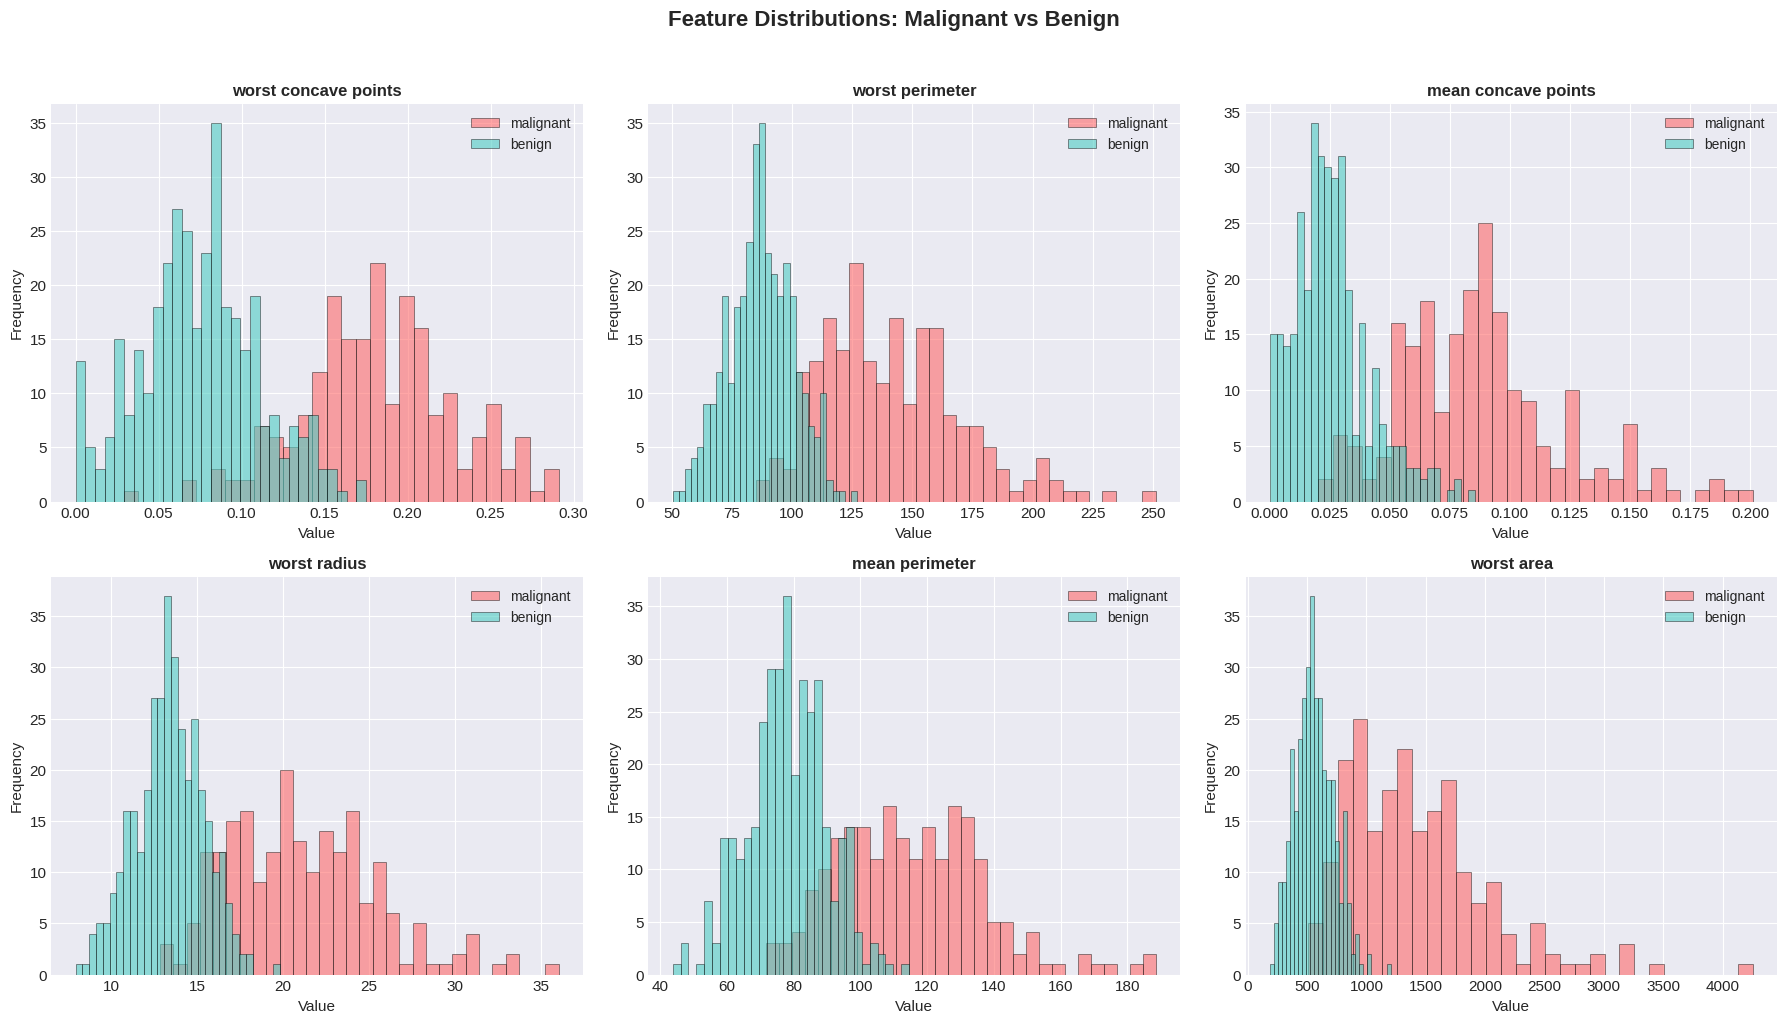

In [15]:
# Histograms — top 6 features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_6):
    for label in [0, 1]:
        subset = data_frame[data_frame['label'] == label]
        axes[idx].hist(
            subset[feature],
            bins=30,
            alpha=0.6,
            label=breast_cancer_dataset.target_names[label],
            color=colors[label],
            edgecolor='black',
            linewidth=0.5
        )
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.suptitle('Feature Distributions: Malignant vs Benign', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Pairplot — Top 4 Features

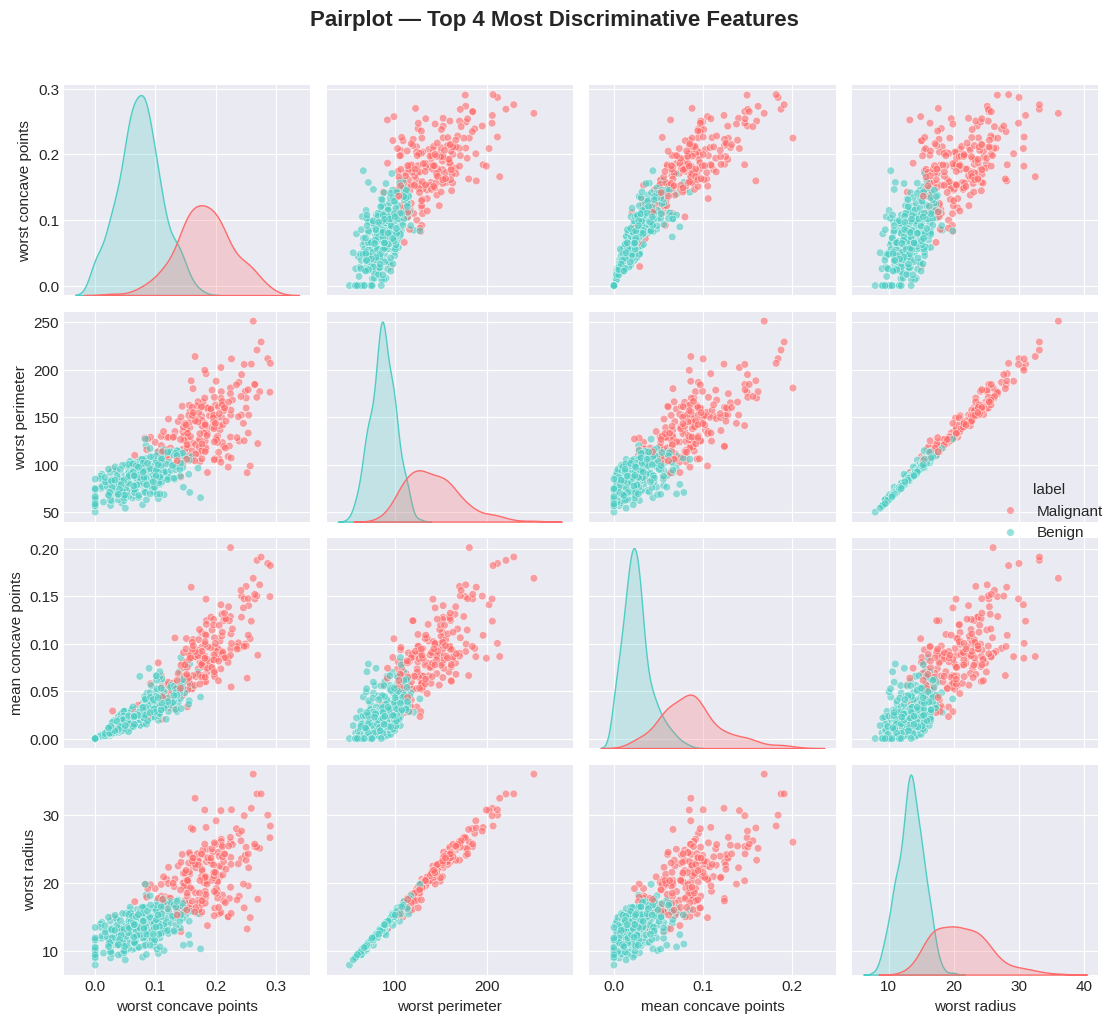

In [16]:
# Pairplot — top 4 features
top_4 = correlations.head(4).index.tolist()
pairplot_data = data_frame[top_4 + ['label']].copy()
pairplot_data['label'] = pairplot_data['label'].map({0: 'Malignant', 1: 'Benign'})

g = sns.pairplot(
    pairplot_data,
    hue='label',
    palette={'Malignant': '#FF6B6B', 'Benign': '#4ECDC4'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'white', 'linewidth': 0.5},
    height=2.5
)
g.figure.suptitle('Pairplot — Top 4 Most Discriminative Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5: Feature Engineering

Analyze feature importance using **Mutual Information** scores and visualize data in reduced dimensions using **PCA (Principal Component Analysis)**.

### 5.1 Mutual Information Scores

Mutual Information measures the dependency between each feature and the target. Higher MI = more useful feature for classification.

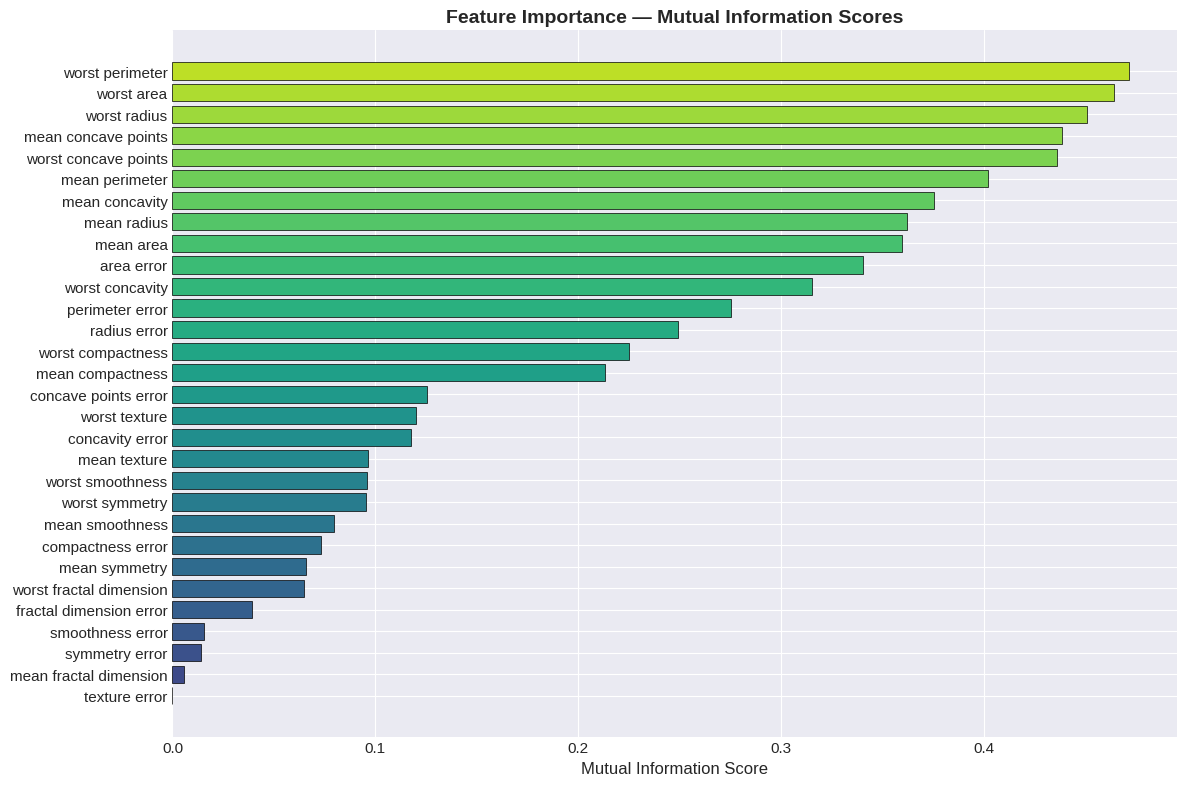


Top 10 Features by Mutual Information:
   1. worst perimeter                | MI = 0.4718
   2. worst area                     | MI = 0.4643
   3. worst radius                   | MI = 0.4512
   4. mean concave points            | MI = 0.4388
   5. worst concave points           | MI = 0.4363
   6. mean perimeter                 | MI = 0.4024
   7. mean concavity                 | MI = 0.3754
   8. mean radius                    | MI = 0.3623
   9. mean area                      | MI = 0.3600
  10. area error                     | MI = 0.3408


In [17]:
# Step 5: Feature Engineering

# Calculate Mutual Information scores
X_features = data_frame.drop(columns='label')
Y_target = data_frame['label']

mi_scores = mutual_info_classif(X_features, Y_target, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_features.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Plot MI scores
plt.figure(figsize=(12, 8))
bars = plt.barh(
    mi_df['Feature'][::-1],
    mi_df['MI_Score'][::-1],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, 30)),
    edgecolor='black',
    linewidth=0.5
)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Feature Importance — Mutual Information Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Features by Mutual Information:")
for i, row in mi_df.head(10).iterrows():
    print(f"  {mi_df.index.get_loc(i)+1:2d}. {row['Feature']:<30s} | MI = {row['MI_Score']:.4f}")

### 5.2 PCA — 2D Visualization

Reduce 30 features to 2 principal components and visualize the class separation.

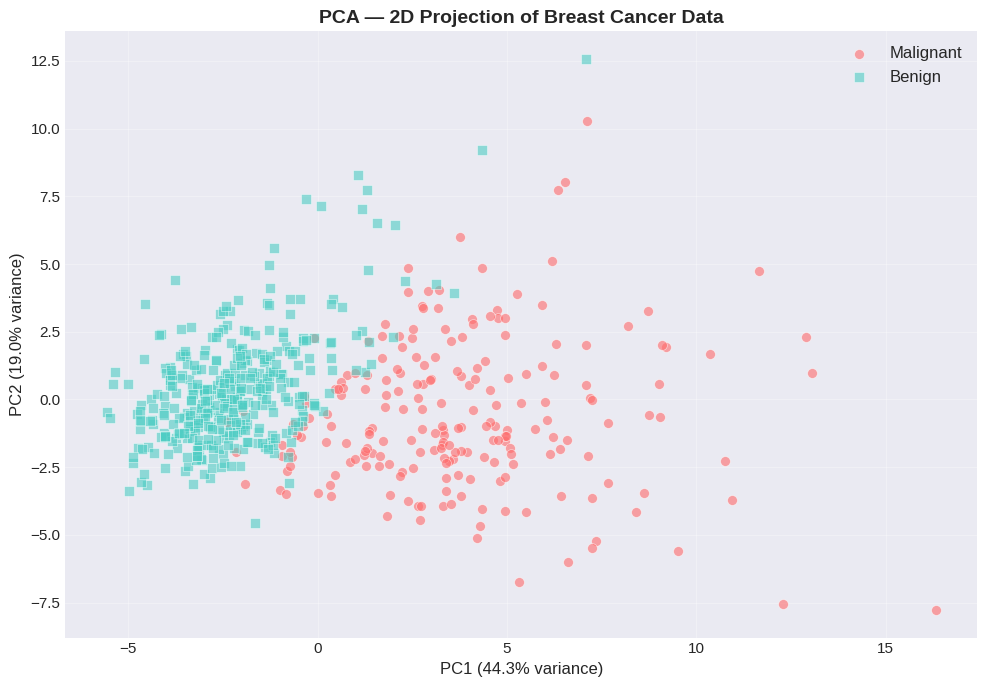


Explained variance: PC1=44.3%, PC2=19.0%
Total variance explained by 2 components: 63.2%


In [18]:
# PCA — 2D projection
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_features)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for label, name, color, marker in [(0, 'Malignant', '#FF6B6B', 'o'), (1, 'Benign', '#4ECDC4', 's')]:
    mask = Y_target == label
    plt.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=color, label=name, alpha=0.6,
        s=50, edgecolors='white', linewidth=0.5, marker=marker
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA — 2D Projection of Breast Cancer Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nExplained variance: PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained by 2 components: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

### 5.3 PCA — 3D Visualization

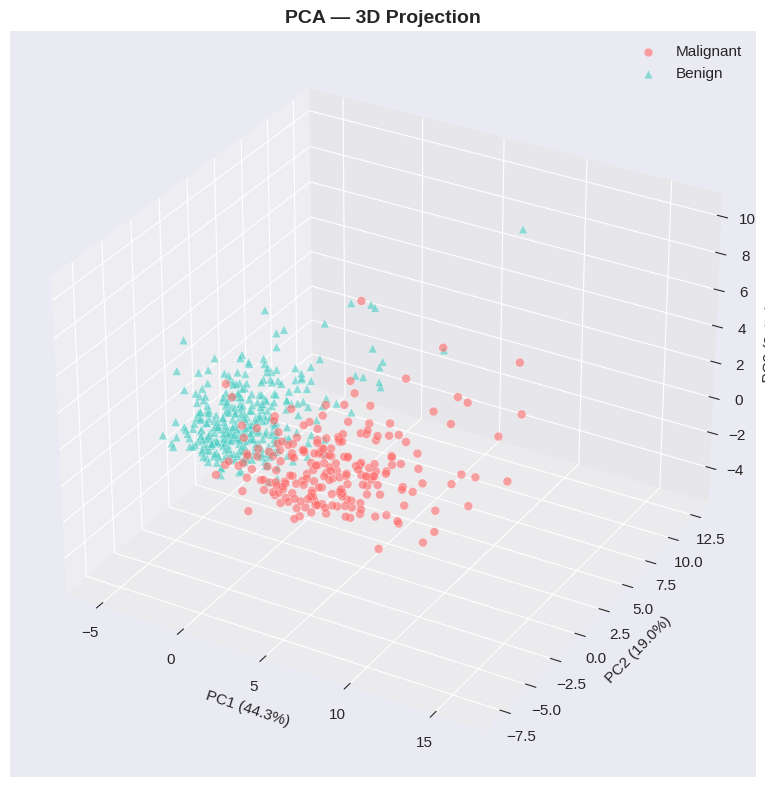

Total variance explained by 3 components: 72.6%


In [19]:
# PCA — 3D projection
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label, name, color, marker in [(0, 'Malignant', '#FF6B6B', 'o'), (1, 'Benign', '#4ECDC4', '^')]:
    mask = Y_target == label
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        c=color, label=name, alpha=0.6,
        s=40, edgecolors='white', linewidth=0.3, marker=marker
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA — 3D Projection', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

total_var = sum(pca_3d.explained_variance_ratio_) * 100
print(f"Total variance explained by 3 components: {total_var:.1f}%")

### 5.4 Explained Variance — Scree Plot

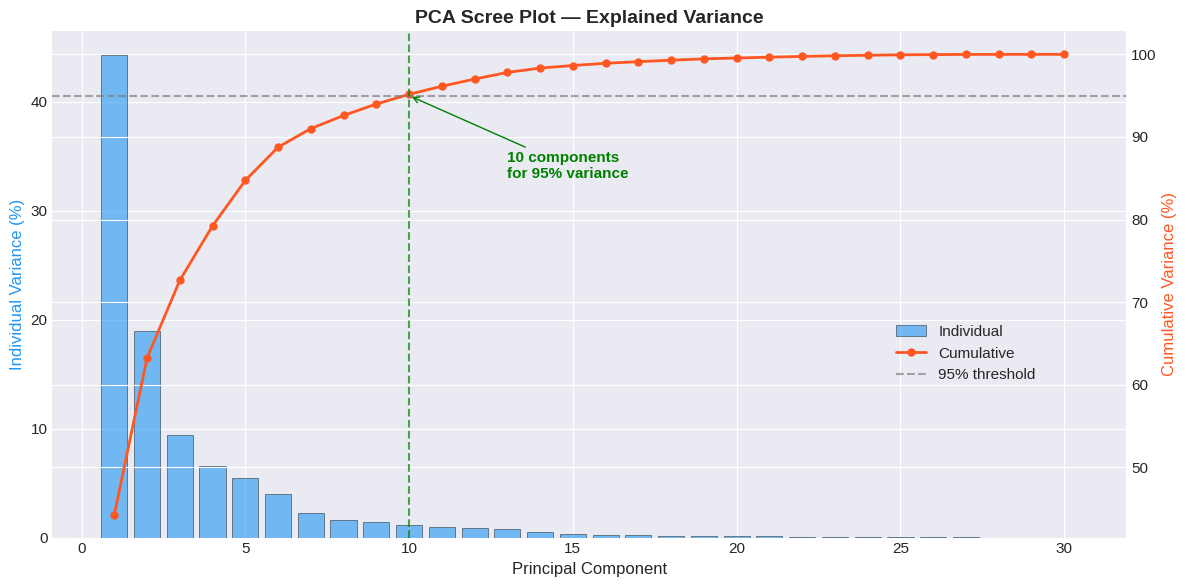


Components needed for 95% variance: 10
Components needed for 99% variance: 17


In [20]:
# Scree plot — components needed
pca_full = PCA(n_components=30)
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Individual variance
ax1.bar(range(1, 31), pca_full.explained_variance_ratio_ * 100,
        alpha=0.6, color='#2196F3', label='Individual', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Individual Variance (%)', fontsize=12, color='#2196F3')

# Cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, 31), cumulative_var, 'o-', color='#FF5722', linewidth=2, markersize=5, label='Cumulative')
ax2.set_ylabel('Cumulative Variance (%)', fontsize=12, color='#FF5722')
ax2.axhline(y=95, color='gray', linestyle='--', alpha=0.7, label='95% threshold')

# Components for 95% variance
n_95 = np.argmax(cumulative_var >= 95) + 1
ax2.axvline(x=n_95, color='green', linestyle='--', alpha=0.7)
ax2.annotate(f'{n_95} components\nfor 95% variance',
             xy=(n_95, 95), xytext=(n_95+3, 85),
             fontsize=11, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.title('PCA Scree Plot — Explained Variance', fontsize=14, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.4))
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {np.argmax(cumulative_var >= 99) + 1}")

---
## Step 6: Data Preprocessing

Separate features and target, split into training/testing sets with stratification, and standardize features.

In [21]:
# Step 6: Data Preprocessing

# Separate features and target
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

print(f"Features (X) shape: {X.shape}")
print(f"Target (Y) shape:   {Y.shape}")

Features (X) shape: (569, 30)
Target (Y) shape:   (569,)


In [22]:
# Train-test split (80/20, stratified)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{Y_train.value_counts().to_string()}")
print(f"\nTesting class distribution:\n{Y_test.value_counts().to_string()}")

Training set: 455 samples
Testing set:  114 samples

Training class distribution:
label
1    285
0    170

Testing class distribution:
label
1    72
0    42


In [23]:
# Feature Standardization
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)  # Same scaler — no re-fitting!

print(f"Before standardization — Mean: {X_train.values.mean():.2f}, Std: {X_train.values.std():.2f}")
print(f"After standardization  — Mean: {X_train_std.mean():.4f}, Std: {X_train_std.std():.4f}")
print("\nFeatures standardized successfully!")

Before standardization — Mean: 61.21, Std: 224.61
After standardization  — Mean: -0.0000, Std: 1.0000

Features standardized successfully!


---
## Step 7: Model 1 — Logistic Regression (Baseline)

A simple yet powerful linear classifier. This serves as our **baseline model** to compare against more complex models.

In [24]:
# Step 7: Logistic Regression

lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train_std, Y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_std)
lr_test_pred = lr_model.predict(X_test_std)

# Metrics
lr_train_acc = accuracy_score(Y_train, lr_train_pred)
lr_test_acc = accuracy_score(Y_test, lr_test_pred)
lr_precision = precision_score(Y_test, lr_test_pred)
lr_recall = recall_score(Y_test, lr_test_pred)
lr_f1 = f1_score(Y_test, lr_test_pred)

print("=" * 50)
print("  LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"  Training Accuracy: {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)")
print(f"  Testing Accuracy:  {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)")
print(f"  Precision:         {lr_precision:.4f}")
print(f"  Recall:            {lr_recall:.4f}")
print(f"  F1 Score:          {lr_f1:.4f}")
print("=" * 50)

  LOGISTIC REGRESSION RESULTS
  Training Accuracy: 0.9890 (98.90%)
  Testing Accuracy:  0.9825 (98.25%)
  Precision:         0.9861
  Recall:            0.9861
  F1 Score:          0.9861


In [25]:
# Cross-validation (5-fold)
lr_cv_scores = cross_val_score(lr_model, X_train_std, Y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in lr_cv_scores]}")

5-Fold Cross-Validation Accuracy: 0.9802 (+/- 0.0128)
Individual fold scores: ['0.9670', '0.9780', '0.9670', '1.0000', '0.9890']


In [26]:
# Classification Report
print("Classification Report — Logistic Regression:")
print("=" * 60)
print(classification_report(Y_test, lr_test_pred, target_names=breast_cancer_dataset.target_names))

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## Step 8: Model 2 — Support Vector Machine (SVM)

SVM with RBF (Radial Basis Function) kernel — effective for non-linear classification boundaries.

In [27]:
# Step 8: Support Vector Machine

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_std, Y_train)

# Predictions
svm_train_pred = svm_model.predict(X_train_std)
svm_test_pred = svm_model.predict(X_test_std)

# Metrics
svm_train_acc = accuracy_score(Y_train, svm_train_pred)
svm_test_acc = accuracy_score(Y_test, svm_test_pred)
svm_precision = precision_score(Y_test, svm_test_pred)
svm_recall = recall_score(Y_test, svm_test_pred)
svm_f1 = f1_score(Y_test, svm_test_pred)

print("=" * 50)
print("  SVM (RBF KERNEL) RESULTS")
print("=" * 50)
print(f"  Training Accuracy: {svm_train_acc:.4f} ({svm_train_acc*100:.2f}%)")
print(f"  Testing Accuracy:  {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")
print(f"  Precision:         {svm_precision:.4f}")
print(f"  Recall:            {svm_recall:.4f}")
print(f"  F1 Score:          {svm_f1:.4f}")
print("=" * 50)

  SVM (RBF KERNEL) RESULTS
  Training Accuracy: 0.9824 (98.24%)
  Testing Accuracy:  0.9825 (98.25%)
  Precision:         0.9861
  Recall:            0.9861
  F1 Score:          0.9861


In [28]:
# Cross-validation (5-fold)
svm_cv_scores = cross_val_score(svm_model, X_train_std, Y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in svm_cv_scores]}")

5-Fold Cross-Validation Accuracy: 0.9714 (+/- 0.0179)
Individual fold scores: ['0.9560', '0.9890', '0.9451', '0.9780', '0.9890']


In [29]:
# Classification Report
print("Classification Report — SVM:")
print("=" * 60)
print(classification_report(Y_test, svm_test_pred, target_names=breast_cancer_dataset.target_names))

Classification Report — SVM:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## Step 9: Model 3 — Random Forest

An ensemble method that builds multiple decision trees and combines their predictions. Also provides **feature importance** rankings.

In [30]:
# Step 9: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_std, Y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train_std)
rf_test_pred = rf_model.predict(X_test_std)

# Metrics
rf_train_acc = accuracy_score(Y_train, rf_train_pred)
rf_test_acc = accuracy_score(Y_test, rf_test_pred)
rf_precision = precision_score(Y_test, rf_test_pred)
rf_recall = recall_score(Y_test, rf_test_pred)
rf_f1 = f1_score(Y_test, rf_test_pred)

print("=" * 50)
print("  RANDOM FOREST RESULTS")
print("=" * 50)
print(f"  Training Accuracy: {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)")
print(f"  Testing Accuracy:  {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")
print(f"  Precision:         {rf_precision:.4f}")
print(f"  Recall:            {rf_recall:.4f}")
print(f"  F1 Score:          {rf_f1:.4f}")
print("=" * 50)

  RANDOM FOREST RESULTS
  Training Accuracy: 1.0000 (100.00%)
  Testing Accuracy:  0.9561 (95.61%)
  Precision:         0.9589
  Recall:            0.9722
  F1 Score:          0.9655


In [31]:
# Cross-validation (5-fold)
rf_cv_scores = cross_val_score(rf_model, X_train_std, Y_train, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in rf_cv_scores]}")

5-Fold Cross-Validation Accuracy: 0.9538 (+/- 0.0235)
Individual fold scores: ['0.9670', '0.9890', '0.9231', '0.9341', '0.9560']


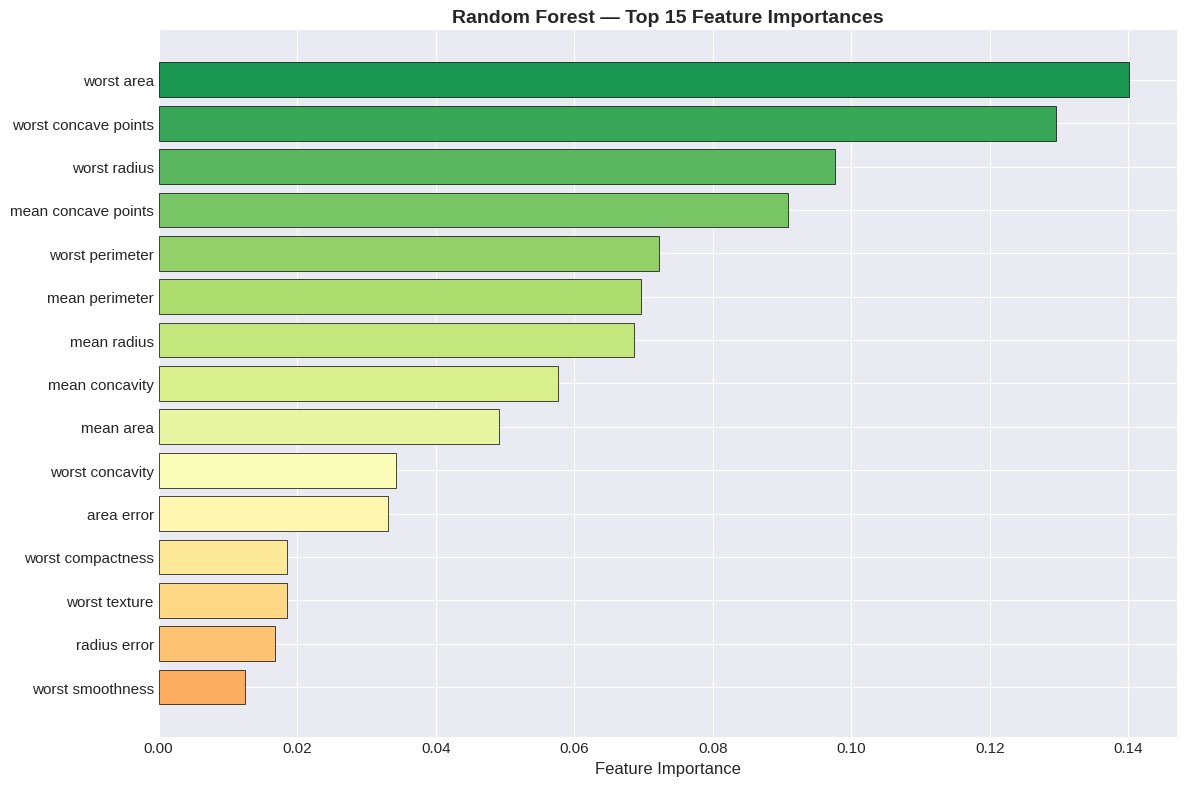

In [32]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
top_15_rf = rf_importance.head(15)
bars = plt.barh(
    top_15_rf['Feature'][::-1],
    top_15_rf['Importance'][::-1],
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15)),
    edgecolor='black',
    linewidth=0.5
)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Classification Report
print("Classification Report — Random Forest:")
print("=" * 60)
print(classification_report(Y_test, rf_test_pred, target_names=breast_cancer_dataset.target_names))

Classification Report — Random Forest:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## Step 10: Multi-Model Comparison (ML Models)

Compare all three ML models side-by-side before training the Neural Network.

In [34]:
# Step 10: Multi-Model Comparison

comparison_data = {
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Random Forest'],
    'Train Accuracy': [lr_train_acc, svm_train_acc, rf_train_acc],
    'Test Accuracy': [lr_test_acc, svm_test_acc, rf_test_acc],
    'Precision': [lr_precision, svm_precision, rf_precision],
    'Recall': [lr_recall, svm_recall, rf_recall],
    'F1 Score': [lr_f1, svm_f1, rf_f1],
    'CV Mean Accuracy': [lr_cv_scores.mean(), svm_cv_scores.mean(), rf_cv_scores.mean()]
}

comparison_df = pd.DataFrame(comparison_data)
print("ML Models Comparison:")
comparison_df

ML Models Comparison:


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy
0,Logistic Regression,0.989011,0.982456,0.986111,0.986111,0.986111,0.980220
1,SVM (RBF),0.982418,0.982456,0.986111,0.986111,0.986111,0.971429
2,Random Forest,1.000000,0.956140,0.958904,0.972222,0.965517,0.953846


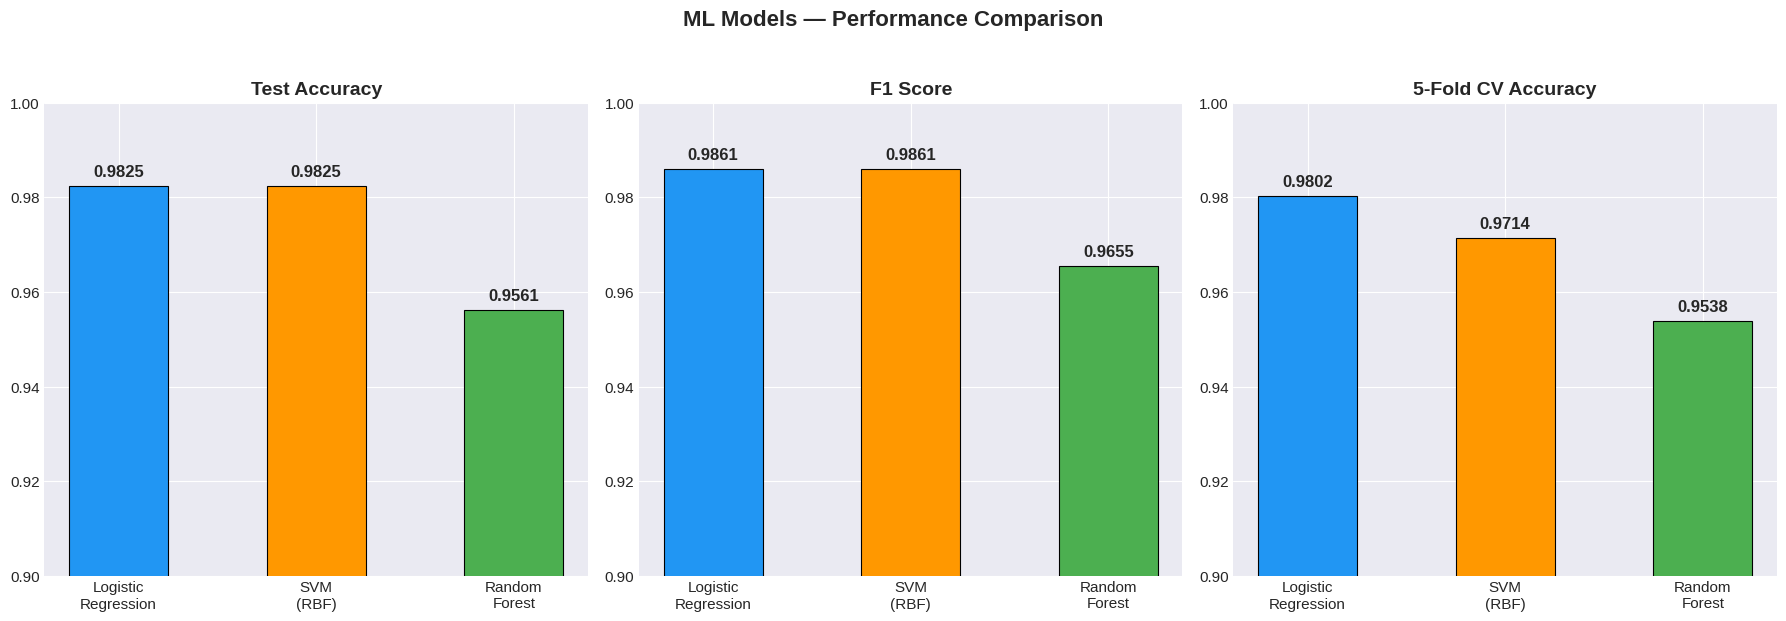

In [35]:
# Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = ['Logistic\nRegression', 'SVM\n(RBF)', 'Random\nForest']
model_colors = ['#2196F3', '#FF9800', '#4CAF50']

# Accuracy comparison
axes[0].bar(model_names, comparison_df['Test Accuracy'], color=model_colors,
            edgecolor='black', linewidth=0.8, width=0.5)
axes[0].set_title('Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.9, 1.0)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# F1 Score comparison
axes[1].bar(model_names, comparison_df['F1 Score'], color=model_colors,
            edgecolor='black', linewidth=0.8, width=0.5)
axes[1].set_title('F1 Score', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.9, 1.0)
for i, v in enumerate(comparison_df['F1 Score']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# CV Accuracy comparison
axes[2].bar(model_names, comparison_df['CV Mean Accuracy'], color=model_colors,
            edgecolor='black', linewidth=0.8, width=0.5)
axes[2].set_title('5-Fold CV Accuracy', fontsize=14, fontweight='bold')
axes[2].set_ylim(0.9, 1.0)
for i, v in enumerate(comparison_df['CV Mean Accuracy']):
    axes[2].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('ML Models — Performance Comparison', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

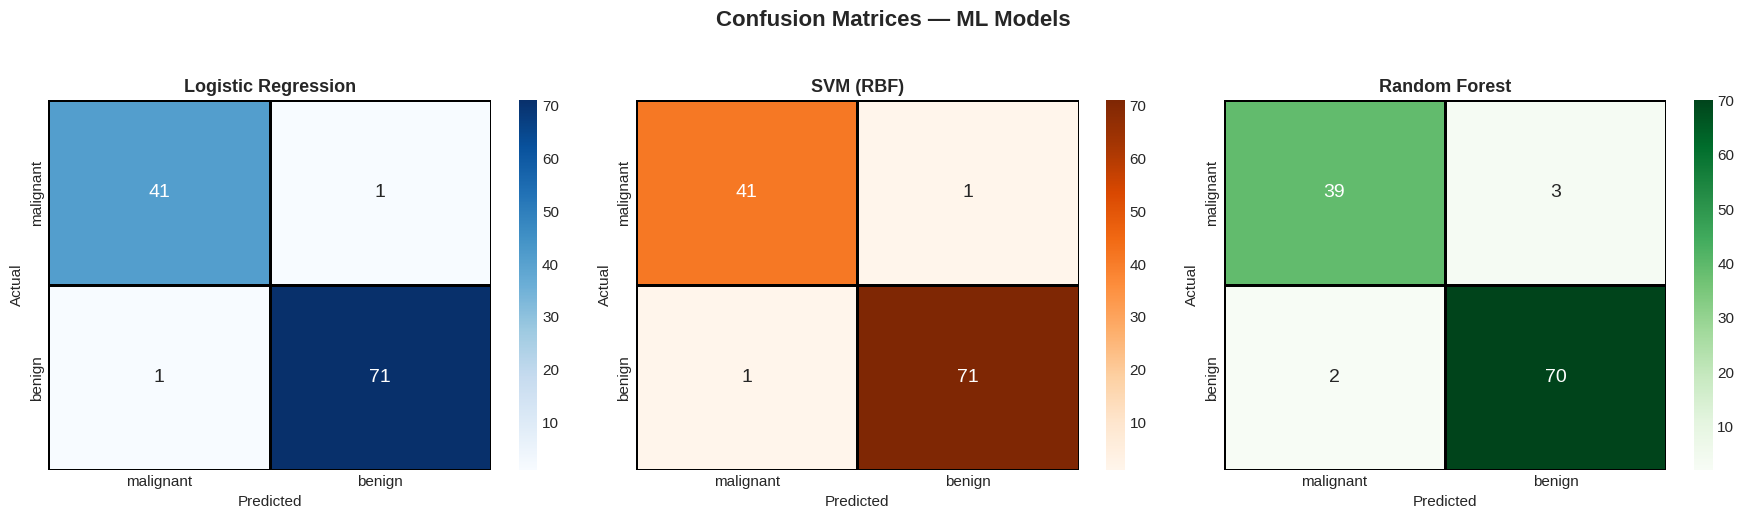

In [36]:
# Confusion matrices — ML models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred, color) in enumerate([
    ('Logistic Regression', lr_test_pred, 'Blues'),
    ('SVM (RBF)', svm_test_pred, 'Oranges'),
    ('Random Forest', rf_test_pred, 'Greens')
]):
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=breast_cancer_dataset.target_names,
        yticklabels=breast_cancer_dataset.target_names,
        linewidths=1, linecolor='black',
        annot_kws={"size": 14},
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — ML Models', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Step 11: Neural Network — Build & Compile

Build a feedforward neural network with:
- **4 Dense layers** with ReLU activation
- **Dropout** layers for regularization
- **Batch Normalization** for stable training
- **Early Stopping** to prevent overfitting
- **Learning Rate Scheduler** for better convergence

In [37]:
# Step 11: Build Neural Network

model = keras.Sequential([
    # Input + Hidden Layer 1
    layers.Dense(256, activation='relu', input_shape=(30,), name='hidden_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    # Hidden Layer 2
    layers.Dense(128, activation='relu', name='hidden_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.3, name='dropout_2'),

    # Hidden Layer 3
    layers.Dense(64, activation='relu', name='hidden_3'),
    layers.Dropout(0.2, name='dropout_3'),

    # Hidden Layer 4
    layers.Dense(32, activation='relu', name='hidden_4'),

    # Output Layer (2 classes)
    layers.Dense(2, activation='softmax', name='output')
], name='BreastCancer_NN')

# Print model summary
model.summary()

Model: "BreastCancer_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,770 (206.13 KB)

 Trainable params: 52,002 (203.13 KB)

 Non-trainable params: 768 (3.00 KB)

In [38]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("Model compiled with:")
print("   • Optimizer: Adam (lr=0.001)")
print("   • Loss: Sparse Categorical Crossentropy")
print("   • Callbacks: EarlyStopping (patience=15), ReduceLROnPlateau (factor=0.5)")

Model compiled with:
   • Optimizer: Adam (lr=0.001)
   • Loss: Sparse Categorical Crossentropy
   • Callbacks: EarlyStopping (patience=15), ReduceLROnPlateau (factor=0.5)


---
## Step 12: Neural Network — Train

In [39]:
# Step 12: Train Neural Network

history = model.fit(
    X_train_std,
    Y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

print(f"\nTraining complete! Stopped at epoch {len(history.history['loss'])} ")

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7953 - loss: 0.4415 - val_accuracy: 0.9275 - val_loss: 0.4529 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9508 - loss: 0.1766 - val_accuracy: 0.9275 - val_loss: 0.3451 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9585 - loss: 0.1359 - val_accuracy: 0.9565 - val_loss: 0.2705 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9663 - loss: 0.1123 - val_accuracy: 0.9710 - val_loss: 0.2308 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9741 - loss: 0.0820 - val_accuracy: 0.9710 - val_loss: 0.1998 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9715 - loss: 0.0754 - val_accuracy: 0.9710 - val_loss: 0.1718 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9689 - loss: 0.0725 - 

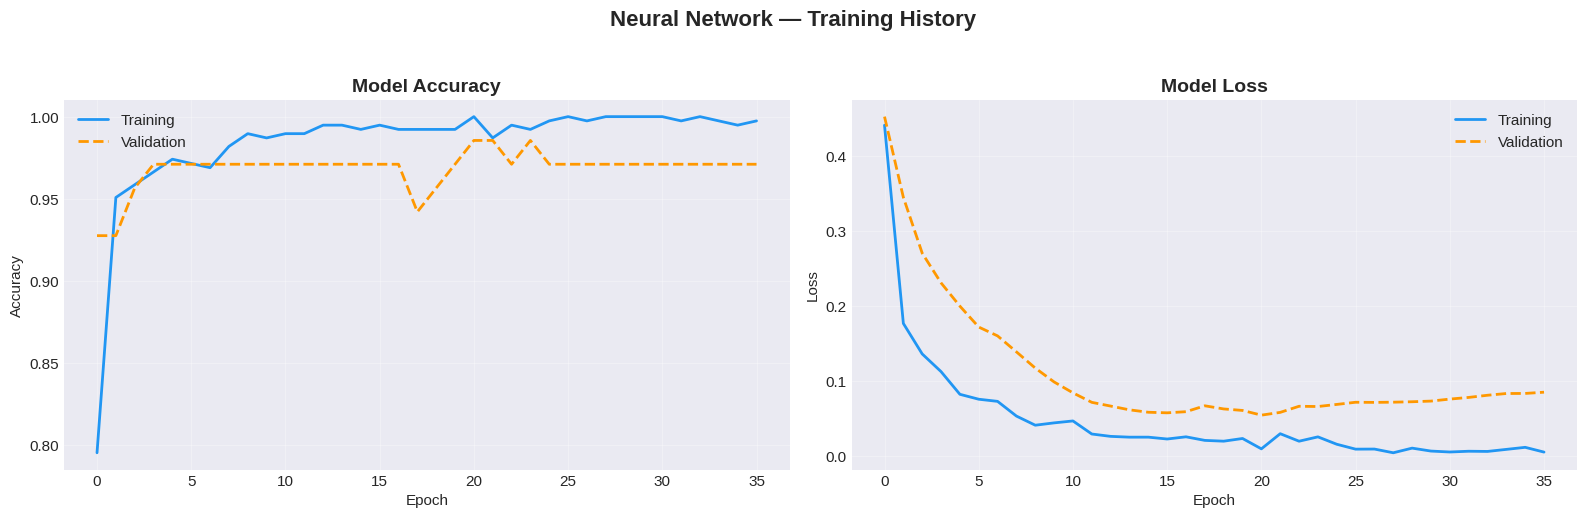

In [40]:
# Training/validation curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2, color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#FF9800', linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2, color='#2196F3')
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#FF9800', linestyle='--')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network — Training History', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [41]:
# NN test evaluation
nn_test_loss, nn_test_acc = model.evaluate(X_test_std, Y_test, verbose=0)

# Get predictions
nn_pred_probs = model.predict(X_test_std, verbose=0)
nn_test_pred = np.argmax(nn_pred_probs, axis=1)

nn_precision = precision_score(Y_test, nn_test_pred)
nn_recall = recall_score(Y_test, nn_test_pred)
nn_f1 = f1_score(Y_test, nn_test_pred)

print("=" * 50)
print("  NEURAL NETWORK RESULTS")
print("=" * 50)
print(f"  Test Loss:     {nn_test_loss:.4f}")
print(f"  Test Accuracy: {nn_test_acc:.4f} ({nn_test_acc*100:.2f}%)")
print(f"  Precision:     {nn_precision:.4f}")
print(f"  Recall:        {nn_recall:.4f}")
print(f"  F1 Score:      {nn_f1:.4f}")
print("=" * 50)

  NEURAL NETWORK RESULTS
  Test Loss:     0.1634
  Test Accuracy: 0.9561 (95.61%)
  Precision:     0.9718
  Recall:        0.9583
  F1 Score:      0.9650


In [42]:
# Classification Report
print("Classification Report — Neural Network:")
print("=" * 60)
print(classification_report(Y_test, nn_test_pred, target_names=breast_cancer_dataset.target_names))

Classification Report — Neural Network:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## Step 13: Advanced Evaluation — All Models

Compare all 4 models with ROC curves, confusion matrices, and a final comparison table.

### 13.1 Final Model Comparison Table

In [43]:
# Step 13: Advanced Evaluation

# Add NN to comparison
final_comparison = {
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Random Forest', 'Neural Network'],
    'Test Accuracy': [lr_test_acc, svm_test_acc, rf_test_acc, nn_test_acc],
    'Precision': [lr_precision, svm_precision, rf_precision, nn_precision],
    'Recall': [lr_recall, svm_recall, rf_recall, nn_recall],
    'F1 Score': [lr_f1, svm_f1, rf_f1, nn_f1]
}

final_df = pd.DataFrame(final_comparison)
print("\n" + "=" * 70)
print("  FINAL MODEL COMPARISON — ALL 4 MODELS")
print("=" * 70)
final_df


  FINAL MODEL COMPARISON — ALL 4 MODELS


,Model,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,SVM (RBF),0.982456,0.986111,0.986111,0.986111
2,Random Forest,0.956140,0.958904,0.972222,0.965517
3,Neural Network,0.956140,0.971831,0.958333,0.965035


### 13.2 Final Comparison — Bar Charts

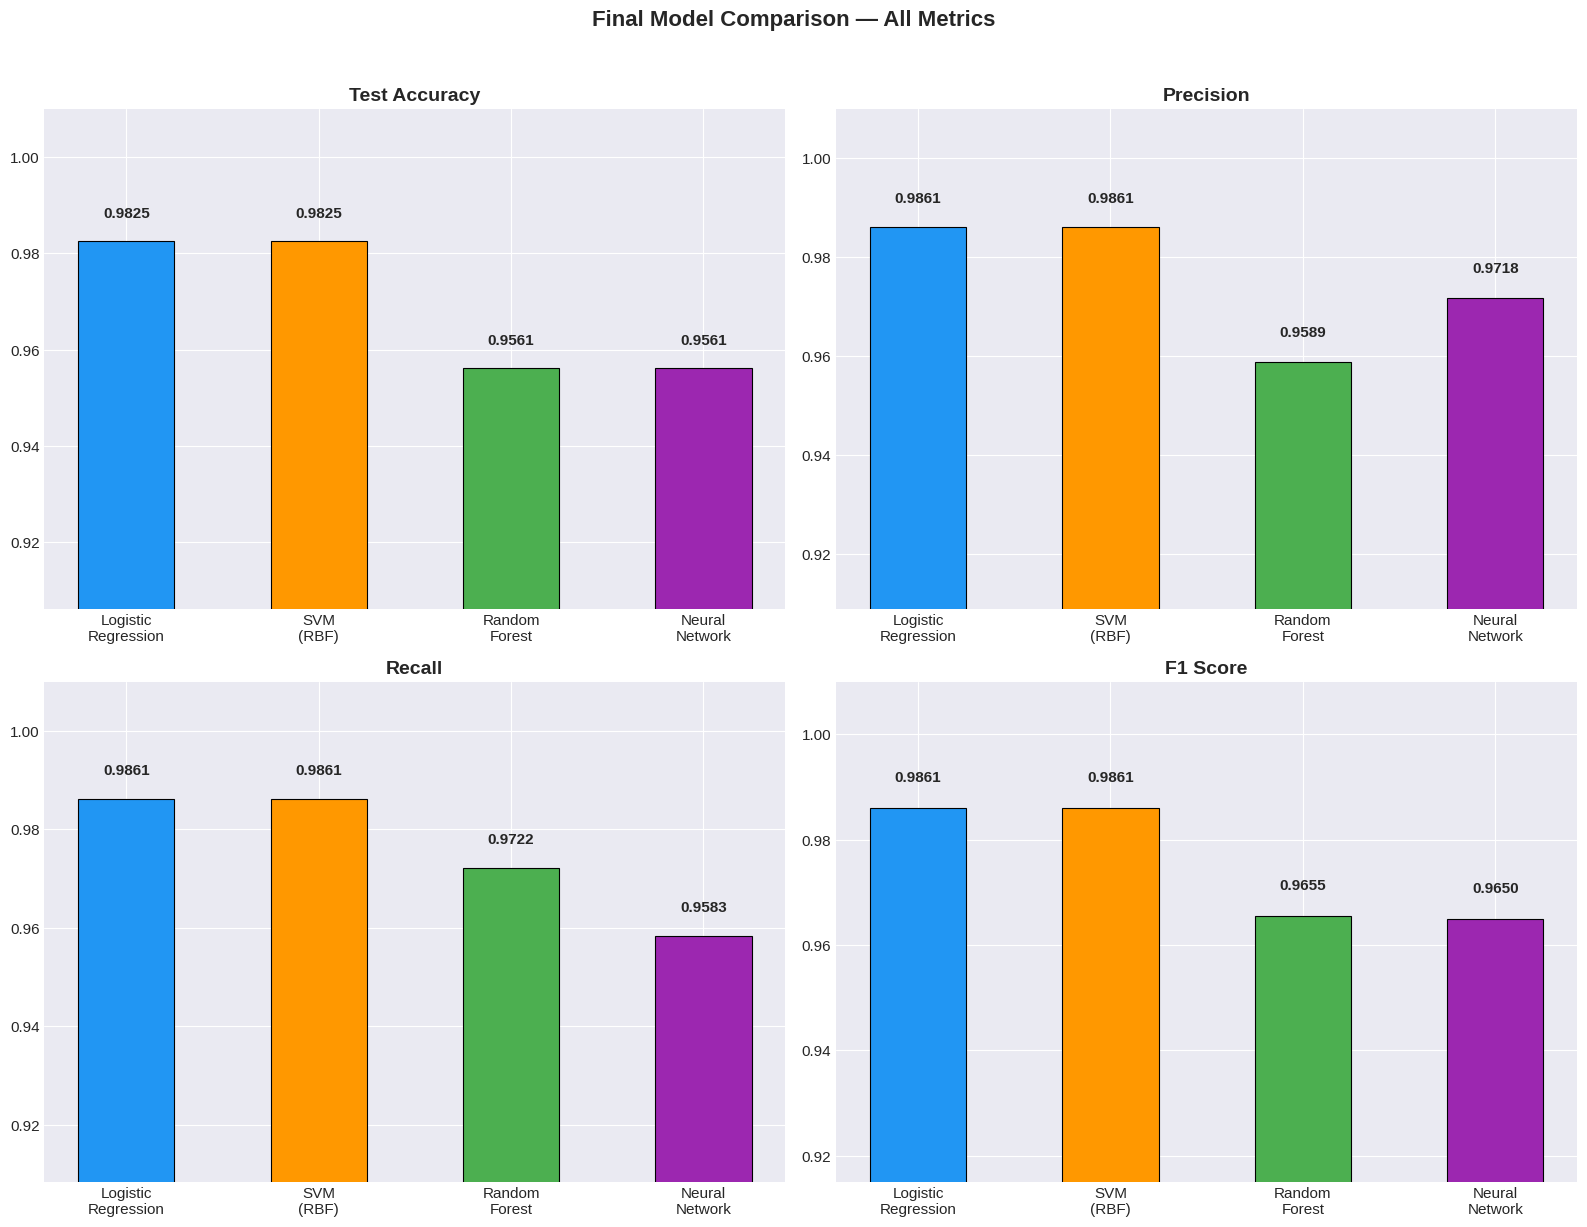

In [44]:
# Final comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_names = ['Logistic\nRegression', 'SVM\n(RBF)', 'Random\nForest', 'Neural\nNetwork']
model_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

metrics = [
    ('Test Accuracy', 'Test Accuracy'),
    ('Precision', 'Precision'),
    ('Recall', 'Recall'),
    ('F1 Score', 'F1 Score')
]

for idx, (metric_name, col) in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    values = final_df[col].values
    bars = ax.bar(model_names, values, color=model_colors,
                  edgecolor='black', linewidth=0.8, width=0.5)
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_ylim(min(values) - 0.05, 1.01)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Final Model Comparison — All Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 13.3 Confusion Matrices — All 4 Models

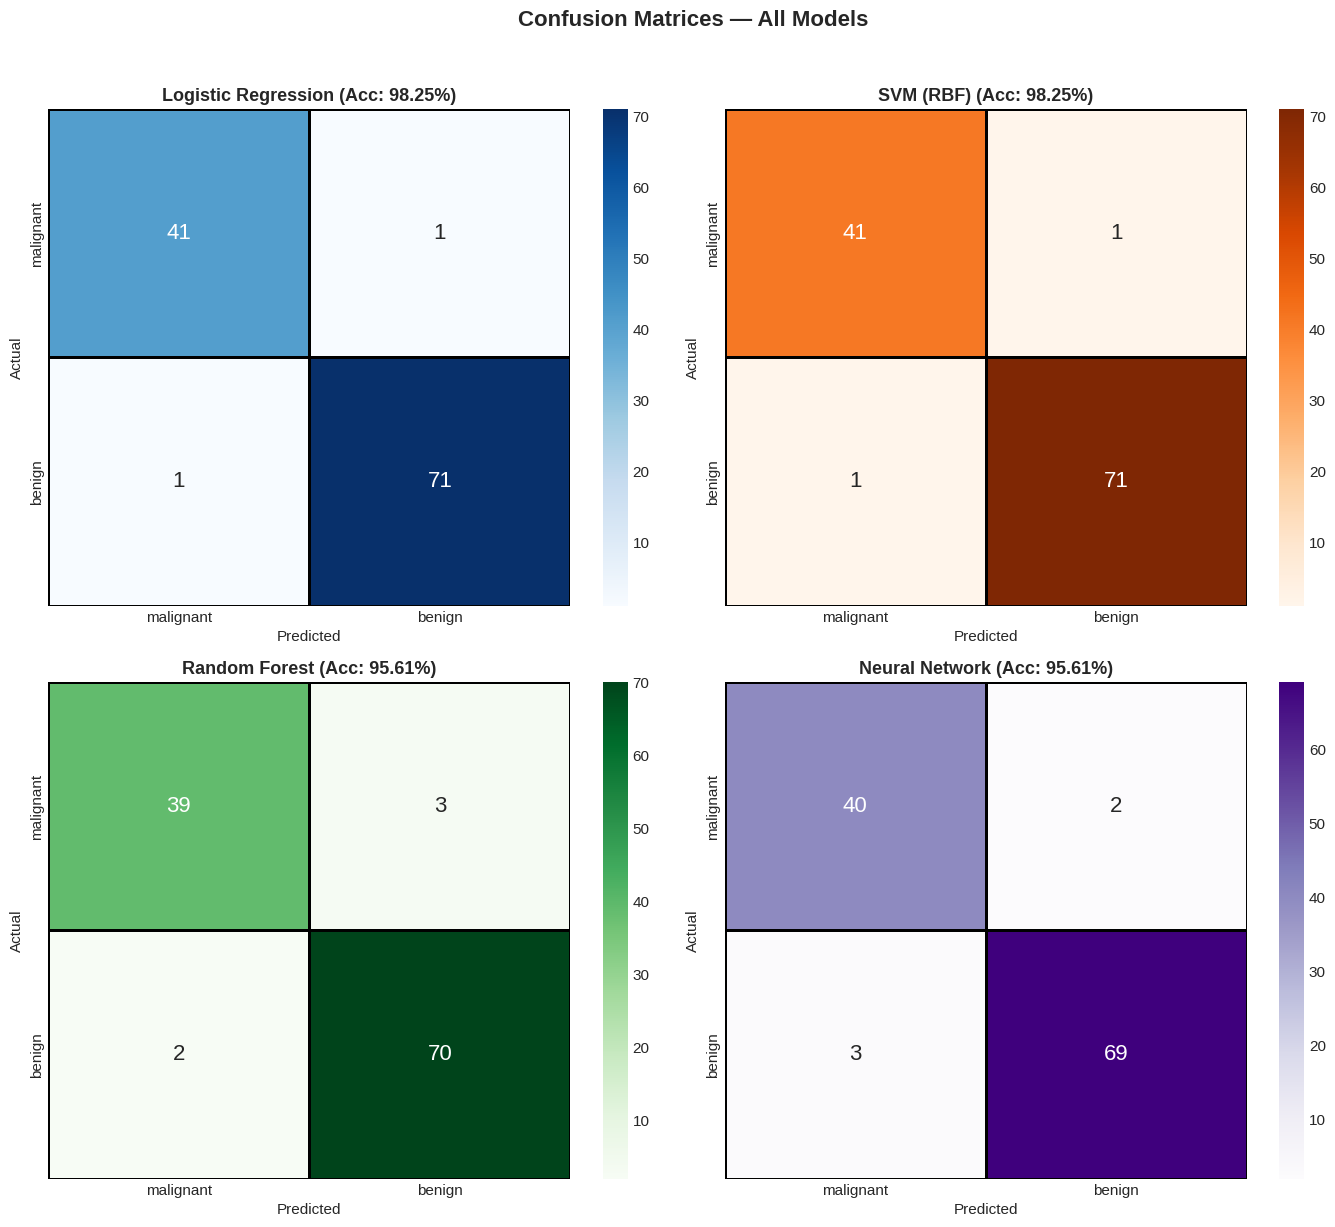

In [45]:
# Confusion matrices — 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

all_models = [
    ('Logistic Regression', lr_test_pred, 'Blues'),
    ('SVM (RBF)', svm_test_pred, 'Oranges'),
    ('Random Forest', rf_test_pred, 'Greens'),
    ('Neural Network', nn_test_pred, 'Purples')
]

for idx, (name, y_pred, cmap) in enumerate(all_models):
    ax = axes[idx // 2][idx % 2]
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=breast_cancer_dataset.target_names,
        yticklabels=breast_cancer_dataset.target_names,
        linewidths=1, linecolor='black',
        annot_kws={"size": 16}, ax=ax
    )
    acc = accuracy_score(Y_test, y_pred)
    ax.set_title(f'{name} (Acc: {acc:.2%})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 13.4 ROC Curves — All 4 Models

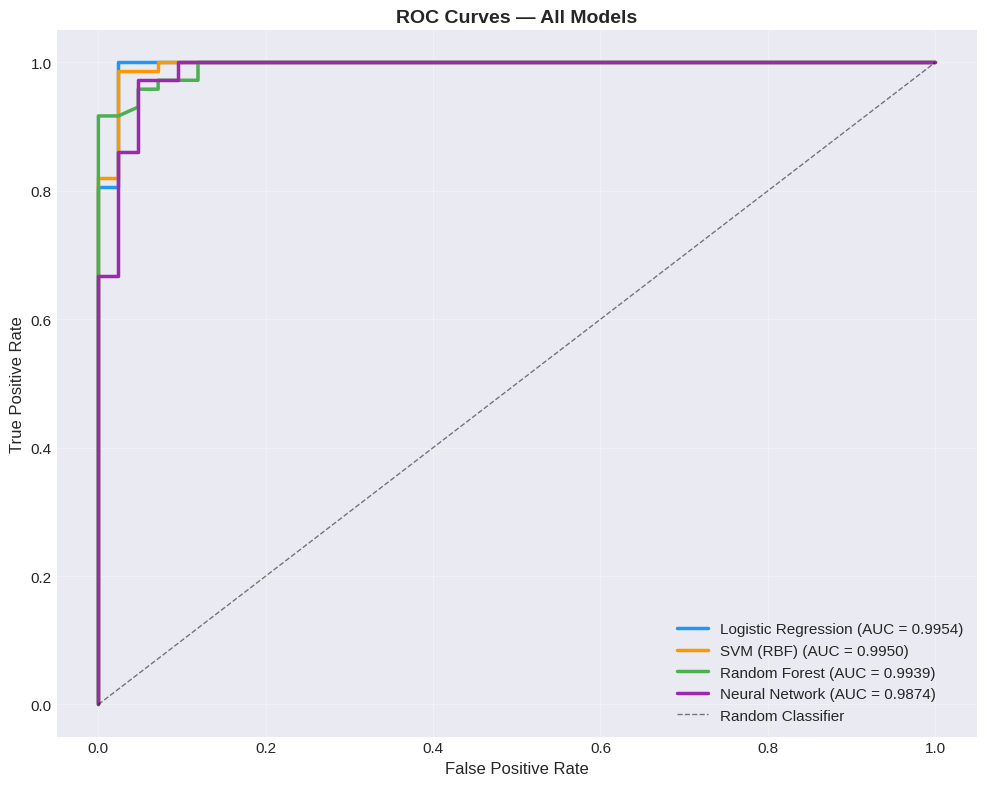


AUC Scores:
  Logistic Regression       | AUC = 0.9954
  SVM (RBF)                 | AUC = 0.9950
  Random Forest             | AUC = 0.9939
  Neural Network            | AUC = 0.9874


In [46]:
# ROC curves
plt.figure(figsize=(10, 8))

# Get probability predictions
models_roc = {
    'Logistic Regression': lr_model.predict_proba(X_test_std)[:, 1],
    'SVM (RBF)': svm_model.predict_proba(X_test_std)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test_std)[:, 1],
    'Neural Network': nn_pred_probs[:, 1]
}

roc_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
auc_scores = {}

for (name, y_proba), color in zip(models_roc.items(), roc_colors):
    fpr, tpr, _ = roc_curve(Y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for name, score in auc_scores.items():
    print(f"  {name:<25s} | AUC = {score:.4f}")

### 13.5 Precision-Recall Curves

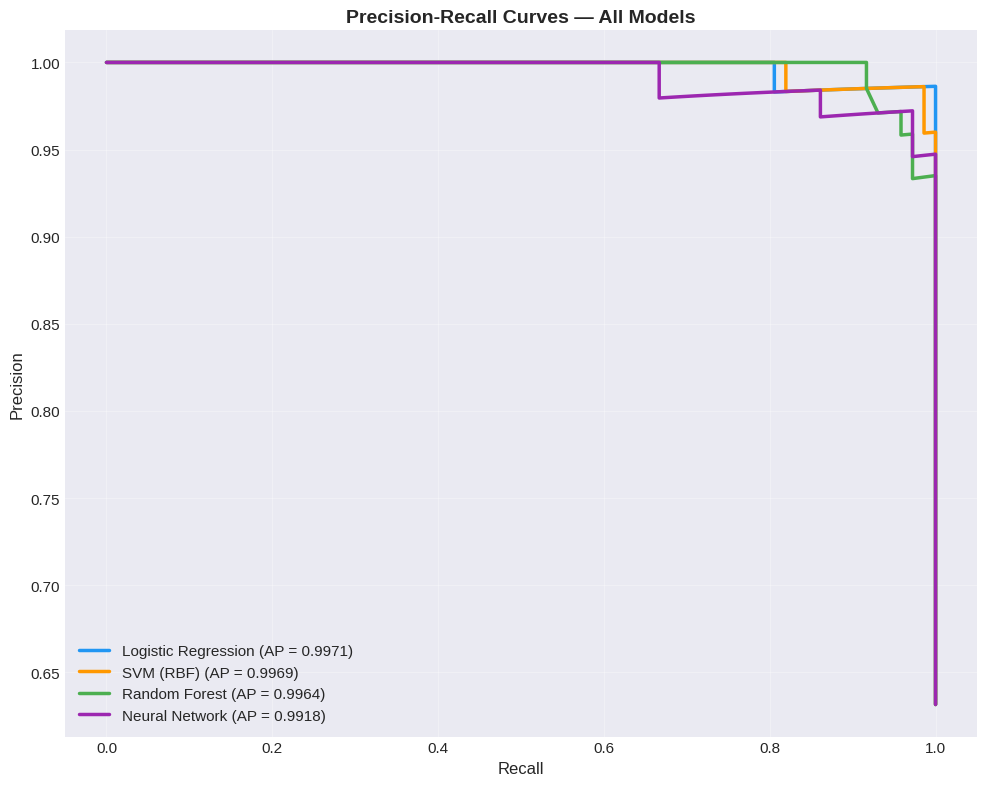

In [47]:
# Precision-Recall Curves
plt.figure(figsize=(10, 8))

for (name, y_proba), color in zip(models_roc.items(), roc_colors):
    precision_vals, recall_vals, _ = precision_recall_curve(Y_test, y_proba)
    avg_precision = average_precision_score(Y_test, y_proba)
    plt.plot(recall_vals, precision_vals, color=color, linewidth=2.5,
             label=f'{name} (AP = {avg_precision:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13.6 Misclassification Analysis (Neural Network)

Which samples did the Neural Network get wrong? Let's investigate.

In [48]:
# Misclassification Analysis
misclassified_mask = nn_test_pred != Y_test.values
misclassified_indices = Y_test.index[misclassified_mask]
n_misclassified = misclassified_mask.sum()

print(f"Total test samples: {len(Y_test)}")
print(f"Correctly classified: {len(Y_test) - n_misclassified}")
print(f"Misclassified: {n_misclassified}")
print(f"Error rate: {n_misclassified/len(Y_test)*100:.2f}%")

if n_misclassified > 0:
    print(f"\nMisclassified sample details:")
    print("-" * 60)
    for idx in misclassified_indices:
        actual = breast_cancer_dataset.target_names[Y_test.loc[idx]]
        predicted = breast_cancer_dataset.target_names[nn_test_pred[Y_test.index.get_loc(idx)]]
        prob = nn_pred_probs[Y_test.index.get_loc(idx)]
        print(f"  Sample {idx}: Actual={actual:>9s}, Predicted={predicted:>9s} "
              f"| Prob: Malignant={prob[0]:.3f}, Benign={prob[1]:.3f}")
else:
    print("\nPerfect classification — no misclassified samples!")

Total test samples: 114
Correctly classified: 109
Misclassified: 5
Error rate: 4.39%

Misclassified sample details:
------------------------------------------------------------
  Sample 363: Actual=   benign, Predicted=malignant | Prob: Malignant=0.919, Benign=0.081
  Sample 542: Actual=   benign, Predicted=malignant | Prob: Malignant=0.909, Benign=0.091
  Sample 73: Actual=malignant, Predicted=   benign | Prob: Malignant=0.001, Benign=0.999
  Sample 291: Actual=   benign, Predicted=malignant | Prob: Malignant=0.781, Benign=0.219
  Sample 205: Actual=malignant, Predicted=   benign | Prob: Malignant=0.021, Benign=0.979


---
## Step 14: Build a Predictive System

Create a reusable function that takes new patient data and predicts whether the tumor is Malignant or Benign using all 4 models.

In [49]:
# Step 14: Predictive System

def predict_cancer(input_data, scaler, models_dict):
    """
    Predict whether a tumor is Malignant or Benign using multiple models.

    Parameters:
        input_data: tuple/list of 30 feature values
        scaler: fitted StandardScaler
        models_dict: dict of {model_name: model_object}

    Returns:
        DataFrame with predictions from all models
    """
    # Preprocess
    input_array = np.asarray(input_data).reshape(1, -1)
    input_std = scaler.transform(input_array)

    print("=" * 65)
    print("  CANCER CLASSIFICATION — PREDICTION RESULTS")
    print("=" * 65)

    results = []
    for name, mdl in models_dict.items():
        if name == 'Neural Network':
            probs = mdl.predict(input_std, verbose=0)
            pred_class = np.argmax(probs)
            confidence = probs[0][pred_class] * 100
        else:
            pred_class = mdl.predict(input_std)[0]
            probs = mdl.predict_proba(input_std)
            confidence = probs[0][pred_class] * 100

        class_name = breast_cancer_dataset.target_names[pred_class]
        results.append({
            'Model': name,
            'Prediction': class_name,
            'Confidence': f'{confidence:.2f}%'
        })
        status_indicator = "Malignant" if pred_class == 0 else "Benign"
        print(f"  [{status_indicator}] {name:<25s} → {class_name:>9s} ({confidence:.2f}%)")

    print("=" * 65)

    # Consensus
    predictions = [r['Prediction'] for r in results]
    consensus = max(set(predictions), key=predictions.count)
    agreement = predictions.count(consensus) / len(predictions) * 100
    print(f"\n  Consensus: {consensus.upper()} ({agreement:.0f}% model agreement)")
    print("=" * 65)

    return pd.DataFrame(results)

In [50]:
# Prepare models dictionary
all_models_dict = {
    'Logistic Regression': lr_model,
    'SVM (RBF)': svm_model,
    'Random Forest': rf_model,
    'Neural Network': model
}

### Test Case 1: Known Malignant Sample

In [51]:
# Known malignant sample
malignant_sample = (17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471,
                    0.2419, 0.07871, 1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904,
                    0.05373, 0.01587, 0.03003, 0.006193, 25.38, 17.33, 184.6, 2019.0,
                    0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189)

print("TEST CASE 1: Known Malignant Sample\n")
result_df = predict_cancer(malignant_sample, scaler, all_models_dict)

TEST CASE 1: Known Malignant Sample

  CANCER CLASSIFICATION — PREDICTION RESULTS
  [Malignant] Logistic Regression       → malignant (100.00%)
  [Malignant] SVM (RBF)                 → malignant (97.55%)
  [Malignant] Random Forest             → malignant (97.00%)
  [Malignant] Neural Network            → malignant (99.97%)

  Consensus: MALIGNANT (100% model agreement)


### Test Case 2: Known Benign Sample

In [52]:
# Known benign sample
benign_sample = (13.54, 14.36, 87.46, 566.3, 0.09779, 0.08129, 0.06664, 0.04781,
                 0.1885, 0.05766, 0.2699, 0.7886, 2.058, 23.56, 0.008462, 0.0146,
                 0.02387, 0.01315, 0.0198, 0.0023, 15.11, 19.26, 99.7, 711.2,
                 0.144, 0.1773, 0.239, 0.1288, 0.2977, 0.07259)

print("TEST CASE 2: Known Benign Sample\n")
result_df = predict_cancer(benign_sample, scaler, all_models_dict)

TEST CASE 2: Known Benign Sample

  CANCER CLASSIFICATION — PREDICTION RESULTS
  [Benign] Logistic Regression       →    benign (91.46%)
  [Benign] SVM (RBF)                 →    benign (98.80%)
  [Benign] Random Forest             →    benign (97.00%)
  [Benign] Neural Network            →    benign (99.99%)

  Consensus: BENIGN (100% model agreement)


---
## Step 15: Save & Load Model

Save the trained Neural Network and the scaler for future use / deployment.

In [53]:
# Step 15: Save & Load Model
import pickle

# Save NN model
model.save('breast_cancer_nn_model.keras')
print("Neural Network model saved: breast_cancer_nn_model.keras")

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("StandardScaler saved: scaler.pkl")

# Save sklearn models
sklearn_models = {
    'logistic_regression': lr_model,
    'svm': svm_model,
    'random_forest': rf_model
}
with open('sklearn_models.pkl', 'wb') as f:
    pickle.dump(sklearn_models, f)
print("Sklearn models saved: sklearn_models.pkl")

Neural Network model saved: breast_cancer_nn_model.keras
StandardScaler saved: scaler.pkl
Sklearn models saved: sklearn_models.pkl


### Load and verify saved models

In [54]:
# Load saved models
loaded_nn_model = keras.models.load_model('breast_cancer_nn_model.keras')
print("Neural Network model loaded successfully")
print(f"   Model name: {loaded_nn_model.name}")
print(f"   Layers: {len(loaded_nn_model.layers)}")

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
print("Scaler loaded successfully")

with open('sklearn_models.pkl', 'rb') as f:
    loaded_sklearn_models = pickle.load(f)
print(f"Sklearn models loaded: {list(loaded_sklearn_models.keys())}")

# Verify loaded model
test_loss, test_acc = loaded_nn_model.evaluate(X_test_std, Y_test, verbose=0)
print(f"\nVerification — Loaded model test accuracy: {test_acc:.4f}")
print("All models saved and verified successfully!")

Neural Network model loaded successfully
   Model name: BreastCancer_NN
   Layers: 10
Scaler loaded successfully
Sklearn models loaded: ['logistic_regression', 'svm', 'random_forest']

Verification — Loaded model test accuracy: 0.9561
All models saved and verified successfully!


---
## Project Complete!

### Project Summary

| Component | Details |
|-----------|---------|
| **Dataset** | Wisconsin Breast Cancer (569 samples, 30 features) |
| **EDA** | Statistics, distributions, boxplots, violin plots, pairplots |
| **Feature Engineering** | Mutual Information scores, PCA (2D, 3D), Scree plot |
| **Models Compared** | Logistic Regression, SVM (RBF), Random Forest, Neural Network |
| **NN Architecture** | Dense: 256 → 128 → 64 → 32 → 2 (with BatchNorm + Dropout) |
| **Callbacks** | EarlyStopping (patience=15), ReduceLROnPlateau |
| **Evaluation** | Accuracy, Precision, Recall, F1, ROC/AUC, PR curves, Confusion Matrices |
| **Cross-Validation** | 5-Fold Stratified CV for ML models |
| **Prediction System** | Multi-model consensus with confidence scores |
| **Model Persistence** | Saved NN (.keras), Scaler (.pkl), Sklearn models (.pkl) |

### Key Takeaways
1. **Multiple models** provide a comprehensive comparison and consensus-based prediction
2. **PCA** reveals that the data is largely separable with just 2-3 components
3. **Feature importance** analysis (MI scores + Random Forest) identifies the most discriminative features
4. **ROC/AUC curves** give a threshold-independent measure of model performance
5. **Misclassification analysis** helps understand model weaknesses
6. **Model saving** enables deployment and future inference without retraining